In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [23]:
df = pd.read_csv('car data.csv')

In [24]:
df.head

<bound method NDFrame.head of     Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Selling_type Transmission  Owner  
0         Dealer       Manual      0  
1  

In [25]:
df.describe

<bound method NDFrame.describe of     Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Selling_type Transmission  Owner  
0         Dealer       Manual      0  

In [26]:
df.shape

(301, 9)

Checking for missing values

In [27]:
df.isnull()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
296,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False
298,False,False,False,False,False,False,False,False,False
299,False,False,False,False,False,False,False,False,False


In [28]:
df = pd.read_csv('car data.csv')
print(f"\n Statistical Summary:\n {df.describe().round(2)}")
print(f"\Missing Values:\n{df.isnull().sum()}")


 Statistical Summary:
           Year  Selling_Price  Present_Price  Driven_kms   Owner
count   301.00         301.00         301.00      301.00  301.00
mean   2013.63           4.66           7.63    36947.21    0.04
std       2.89           5.08           8.64    38886.88    0.25
min    2003.00           0.10           0.32      500.00    0.00
25%    2012.00           0.90           1.20    15000.00    0.00
50%    2014.00           3.60           6.40    32000.00    0.00
75%    2016.00           6.00           9.90    48767.00    0.00
max    2018.00          35.00          92.60   500000.00    3.00
\Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [29]:
#    Feature Engineering

In [30]:
df_clean = df.copy()
df_clean.dropna(inplace=True)

# Column for Age of car
current_year = 2026
df_clean['Car_Age'] = current_year - df_clean['Year']

# Drop original year and car name for modeling
drop_cols = [c for c in ['Car_Name', 'Year'] if c in df_clean.columns]
df_model  = df_clean.drop(columns=drop_cols)

# Encode categoricals
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print(f"\n  Features after engineering: {list(df_model.columns)}")
print(f"    Categorical encoded: {cat_cols}")


  Features after engineering: ['Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']
    Categorical encoded: ['Fuel_Type', 'Selling_type', 'Transmission']


In [31]:
#Model Preparation for Training and Testing

In [32]:
target = 'Selling_Price'
X= df_model.drop(columns = [target])
y= df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2,random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.fit_transform(X_test)

print(f"\n Train/Test :{X_train.shape[0]} train | {X_test.shape[0]} test")


 Train/Test :240 train | 61 test


In [33]:
print("          Model Training & Evaluation")

          Model Training & Evaluation


In [34]:
#function to train and evalute the model
def evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    pred= model.predict(X_test)
    MAE= mean_absolute_error(y_test, pred)
    RMSE = np.sqrt(mean_squared_error(y_test,pred))
    r2 = r2_score(y_test, pred)
    return {"MAE":MAE, "RMSE":RMSE, "R2":r2, "pred":pred}

models = {
        "Linear Regression":       LinearRegression(),
        "Decision Tree":           DecisionTreeRegressor(max_depth=8, random_state=42),
        "Random Forest":           RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting":       GradientBoostingRegressor(n_estimators=100, random_state=42),
        "SVR":                     SVR(kernel='rbf', C=10),
    }

results = {}

print("        MODEL COMPARISON RESULTS")


for name, model in models.items():
    res = evaluate(model, X_train_sc, X_test_sc, y_train, y_test)
    results[name] = res
    print(f"\n {name}")
    print(f"   MAE  : {res['MAE']:.4f}")
    print(f"   RMSE : {res['RMSE']:.4f}")
    print(f"   R²   : {res['R2']:.4f}")

        MODEL COMPARISON RESULTS

 Linear Regression
   MAE  : 1.3227
   RMSE : 1.9198
   R²   : 0.8400

 Decision Tree
   MAE  : 1.2708
   RMSE : 2.2687
   R²   : 0.7766

 Random Forest
   MAE  : 0.9731
   RMSE : 1.5360
   R²   : 0.8976

 Gradient Boosting
   MAE  : 1.0806
   RMSE : 1.7505
   R²   : 0.8670

 SVR
   MAE  : 0.9374
   RMSE : 1.3280
   R²   : 0.9234


  BEST MODEL: SVR
  MAE  : 0.9374 Lakhs
  RMSE : 1.3280 Lakhs
  R²   : 0.9234 (92.34% variance explained)


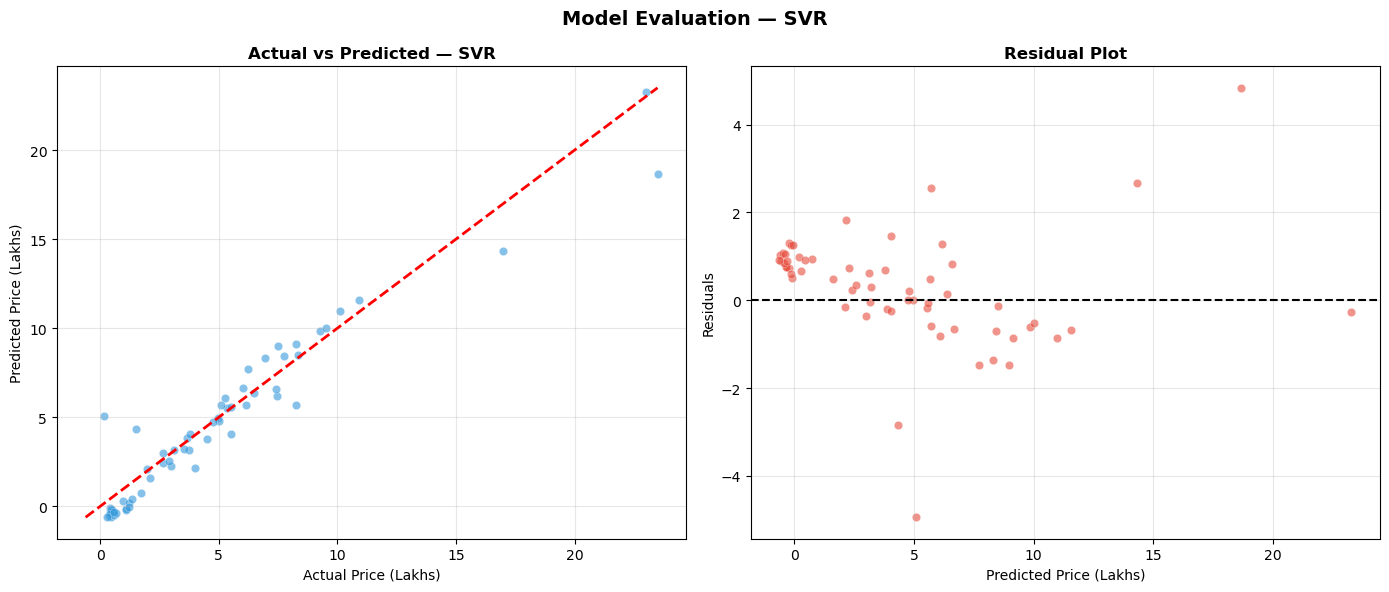


Plot saved: car_price_actual_vs_predicted.png


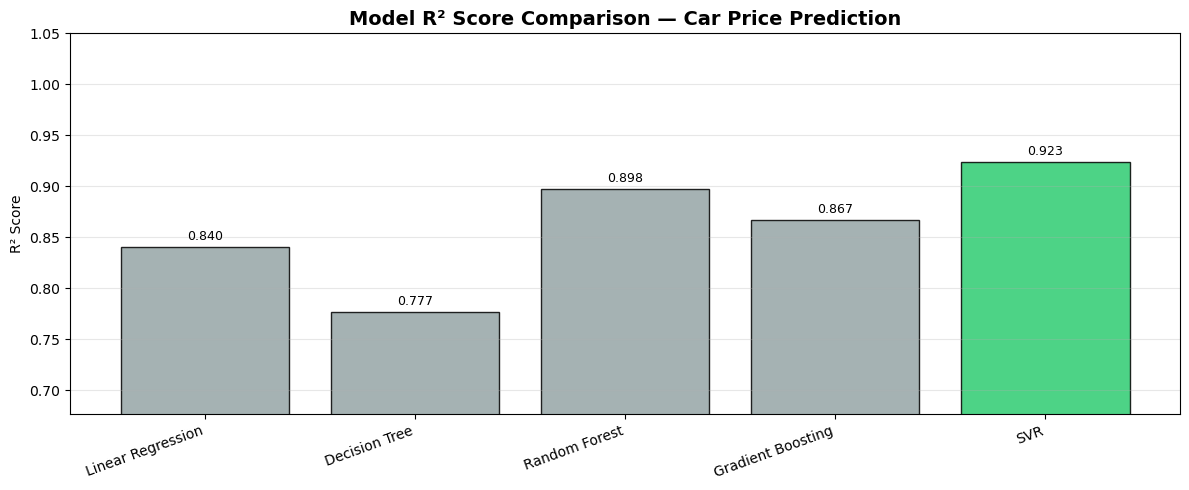

Plot saved: car_price_model_comparison.png


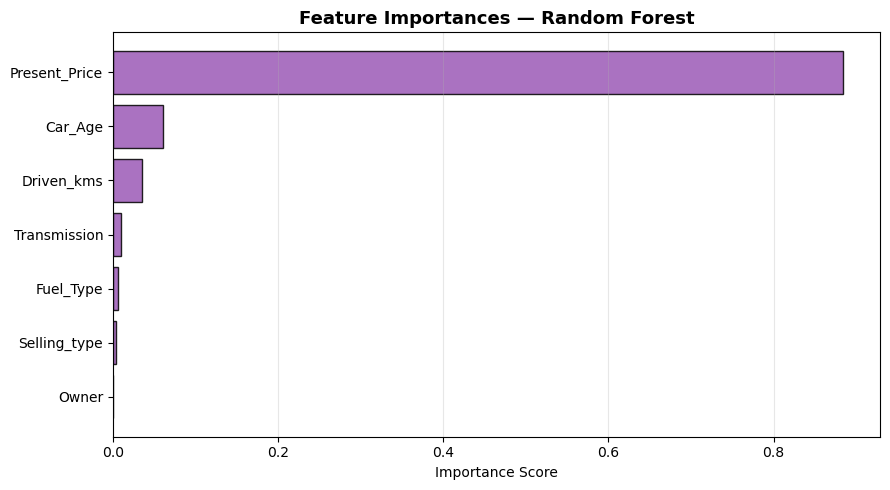

Plot saved: car_price_feature_importance.png


In [35]:
# 6. BEST MODEL — DETAILED EVALUATION

best_name = max(results, key=lambda k: results[k]['R2'])
best_res  = results[best_name]
best_pred = best_res['pred']


print(f"  BEST MODEL: {best_name}")

print(f"  MAE  : {best_res['MAE']:.4f} Lakhs")
print(f"  RMSE : {best_res['RMSE']:.4f} Lakhs")
print(f"  R²   : {best_res['R2']:.4f} ({best_res['R2']*100:.2f}% variance explained)")

# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, best_pred, alpha=0.6, color='#3498db',
                edgecolors='white', linewidths=0.3)
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[0].set_xlabel("Actual Price (Lakhs)")
axes[0].set_ylabel("Predicted Price (Lakhs)")
axes[0].set_title(f"Actual vs Predicted — {best_name}", fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_test.values - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.6, color='#e74c3c',
                edgecolors='white', linewidths=0.3)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel("Predicted Price (Lakhs)")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot", fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle(f"Model Evaluation — {best_name}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("car_price_actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: car_price_actual_vs_predicted.png")

# Model R² Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 5))
names  = list(results.keys())
r2s    = [results[n]['R2'] for n in names]
colors = ['#2ecc71' if n == best_name else '#95a5a6' for n in names]
bars   = ax.bar(names, r2s, color=colors, edgecolor='black', alpha=0.85)
ax.set_ylim(max(0, min(r2s) - 0.1), 1.05)
ax.set_ylabel("R² Score")
ax.set_title("Model R² Score Comparison — Car Price Prediction",
             fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
plt.xticks(rotation=20, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("car_price_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: car_price_model_comparison.png")

# Feature Importance (Random Forest)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color='#9b59b6', edgecolor='black', alpha=0.85)
plt.title("Feature Importances — Random Forest", fontsize=13, fontweight='bold')
plt.xlabel("Importance Score")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("car_price_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: car_price_feature_importance.png")



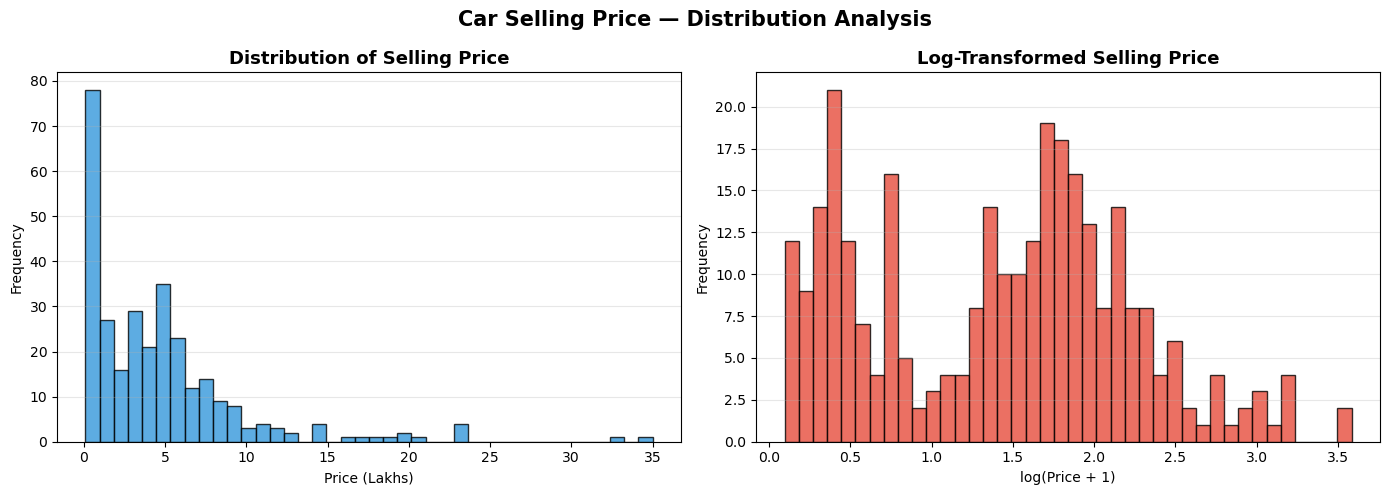


Plot saved: car_price_distribution.png


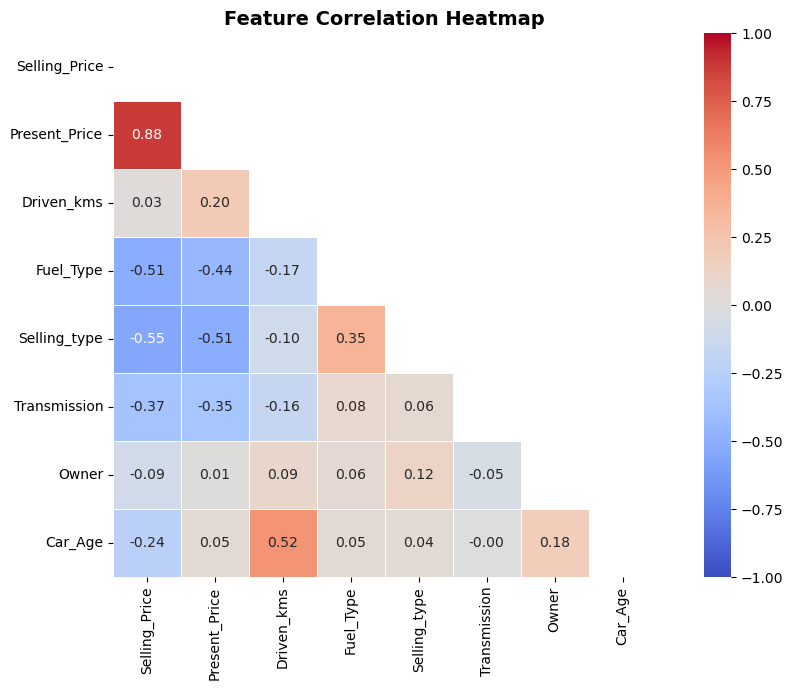

Plot saved: car_price_correlation.png


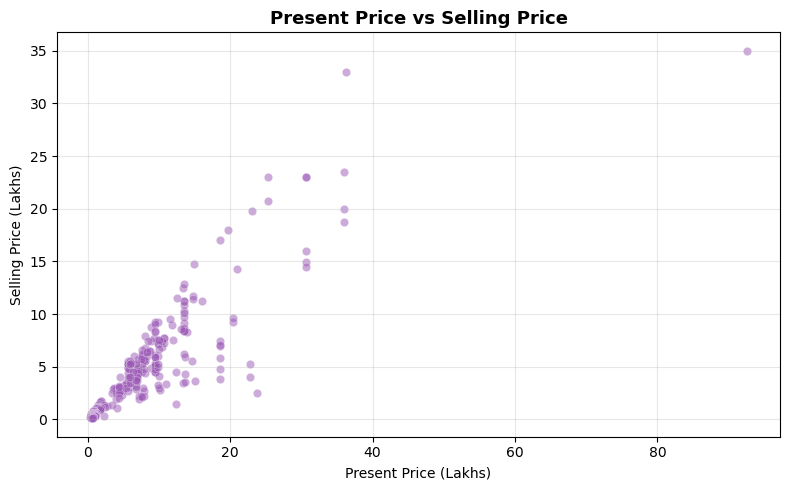

Plot saved: car_price_scatter.png


C:\Users\RICHES\AppData\Local\Temp\ipykernel_12432\1919780400.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Fuel_Type', y=target,


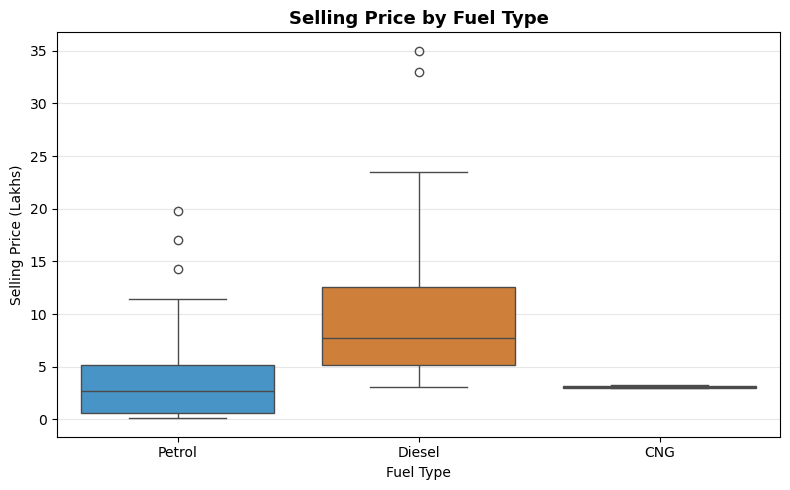

Plot saved: car_price_by_fuel.png


In [36]:

# 3. EDA VISUALIZATIONS

target = 'Selling_Price'

# Distribution of selling price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_clean[target], bins=40, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title("Distribution of Selling Price", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Price (Lakhs)")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(np.log1p(df_clean[target]), bins=40,
             color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_title("Log-Transformed Selling Price", fontsize=13, fontweight='bold')
axes[1].set_xlabel("log(Price + 1)")
axes[1].set_ylabel("Frequency")
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Car Selling Price — Distribution Analysis",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("car_price_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: car_price_distribution.png")

# Correlation Heatmap
plt.figure(figsize=(10, 7))
corr = df_model.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, square=True, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("car_price_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: car_price_correlation.png")

# Scatter: Present Price vs Selling Price
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['Present_Price'], df_clean[target],
            alpha=0.5, color='#9b59b6', edgecolors='white', linewidths=0.3)
plt.xlabel("Present Price (Lakhs)")
plt.ylabel("Selling Price (Lakhs)")
plt.title("Present Price vs Selling Price", fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("car_price_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: car_price_scatter.png")

# Box plot — Fuel Type vs Selling Price (if available)
if 'Fuel_Type' in df_clean.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_clean, x='Fuel_Type', y=target,
                palette=['#3498db', '#e67e22', '#2ecc71'])
    plt.title("Selling Price by Fuel Type", fontsize=13, fontweight='bold')
    plt.xlabel("Fuel Type")
    plt.ylabel("Selling Price (Lakhs)")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig("car_price_by_fuel.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved: car_price_by_fuel.png")